In [1]:
import pandas as pd
import numpy as np
df_cardiac = pd.read_csv("Team05_PyCraft_Cleaned_data/cardiac_cleaned.csv")
df_demography = pd.read_csv("Team05_PyCraft_Cleaned_data/demography_cleaned.csv")
df_hospitalization = pd.read_csv("Team05_PyCraft_Cleaned_data/hospitalization_discharge_cleaned.csv")
df_labs = pd.read_csv("Team05_PyCraft_Cleaned_data/labs_cleaned.csv")
df_patienthistory = pd.read_csv("Team05_PyCraft_Cleaned_data/patienthistory_cleaned.csv")
df_prescriptions = pd.read_csv("Team05_PyCraft_Cleaned_data/precriptions_cleaned.csv")
df_responsiveness = pd.read_csv("Team05_PyCraft_Cleaned_data/responsivenes_cleaned.csv")


## 2. Which medications are most commonly prescribed?

### Reasoning:

Understanding the most frequently prescribed medications helps identify standard treatment patterns for heart-failure patients and reveals which therapies are most commonly used in routine clinical practice. The prescription data contains all medications administered during patient hospitalization.

## Metric Used:
Prescription Frequency
Number of Times Each Drug Appears
Percentage of Patients Receiving Each Medication

## Why These:

Prescription frequency is a simple and effective measure for identifying the medications most commonly used by clinicians. Frequently prescribed drugs often represent guideline-based treatment and standard care practices.



In [2]:
top_drugs = (
    df_prescriptions['drug_name']
    .value_counts()
    .reset_index()
)

top_drugs.columns = [
    'Medication',
    'Prescription_Count'
]

top_drugs.head(20)

,Medication,Prescription_Count
0,Spironolactone Tablet,1833
1,Furosemide Injection,1718
2,Furosemide Tablet,1641
3,Meglumine Adenosine Cyclophosphate For Injection,1114
4,Deslanoside Injection,1015
5,Digoxin Tablet,998
6,Aspirin Enteric-Coated Tablet,958
7,Atorvastatin Calcium Tablet,822
8,Milrinone Injection,707
9,Sulfotanshinone Sodium Injection,570


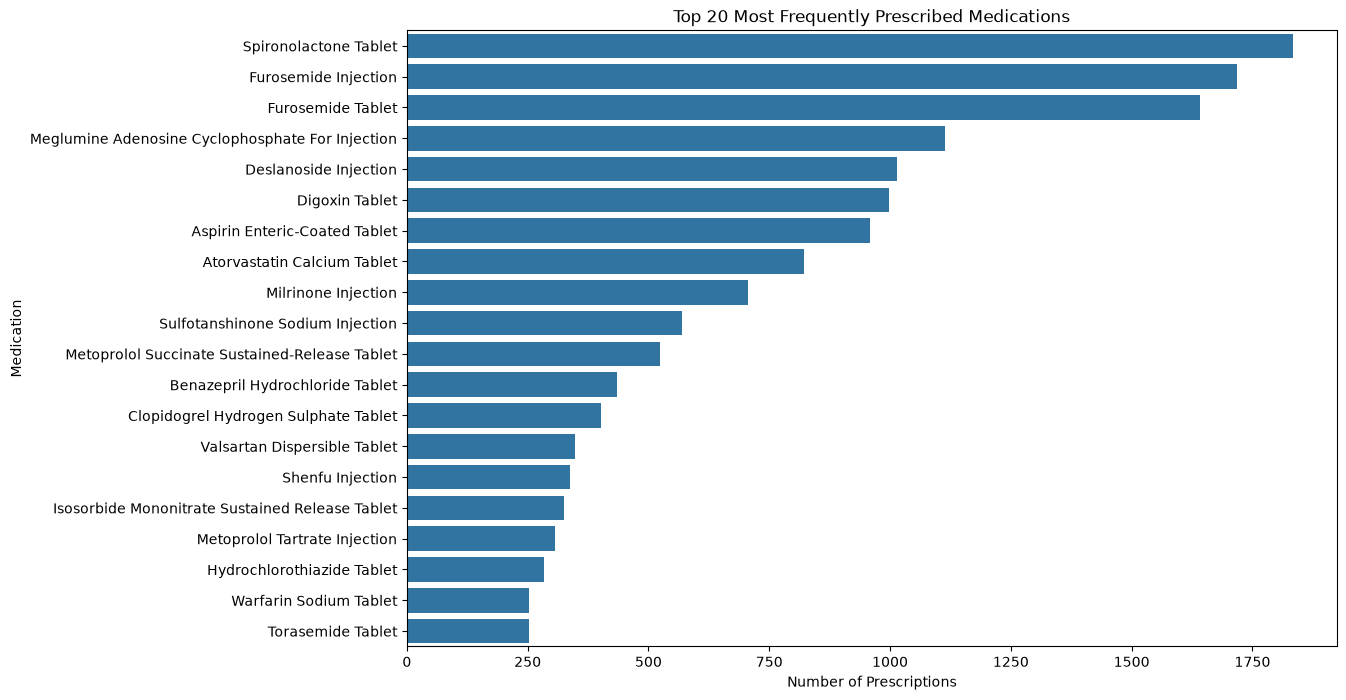

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

top20 = (
    df_prescriptions['drug_name']
    .value_counts()
    .head(20)
    .reset_index()
)

top20.columns = [
    'Medication',
    'Prescription_Count'
]

plt.figure(figsize=(12,8))

sns.barplot(
    data=top20,
    x='Prescription_Count',
    y='Medication'
)

plt.title("Top 20 Most Frequently Prescribed Medications")
plt.xlabel("Number of Prescriptions")
plt.ylabel("Medication")

plt.show()

## Insights:

The most frequently appearing medications in the dataset include:

Spironolactone Tablet
Furosemide Tablet
Furosemide Injection
Digoxin Tablet
Meglumine Adenosine Cyclophosphate For Injection
Atorvastatin Calcium Tablet
Aspirin Enteric-Coated Tablet
Deslanoside Injection
Metoprolol Succinate Sustained-Release Tablet
Clopidogrel Hydrogen Sulphate Tablet

These medications indicate a strong focus on:

Fluid management (diuretics)
Heart-rate control
Cardiac function improvement
Blood-thinning and cardiovascular protection

## How it Helps:
Identifies the most commonly used treatment strategies.
Highlights adherence to heart-failure treatment guidelines.
Supports medication utilization analysis.
Helps evaluate which therapies may be associated with better outcomes in later predictive analysis.
Provides evidence for treatment optimization and clinical decision support.

## 3. Which Laboratory Markers Are Strongest Mortality Indicators?

## Reasoning:
Laboratory biomarkers provide an objective view of a patient's physiological condition and are often early indicators of disease severity. By comparing laboratory values between survivors and non-survivors (death_6m), we can identify biomarkers most strongly associated with mortality risk. labs_cleaned.csv and hospitalization_discharge_cleaned were used for this analysis.

## Metric Used:
6-Month Mortality (death_6m)
Mean Difference Between Survivors and Non-Survivors
Statistical Significance (p-value)
Random Forest Feature Importance (for ranking biomarkers)
## Why These:

These metrics help identify laboratory markers that show the greatest separation between low-risk and high-risk patients. Feature importance and statistical testing provide evidence of which biomarkers contribute most to mortality prediction.


In [4]:
death_6m = 1   # Died within 6 months
death_6m = 0   # Survived

In [5]:
lab_df = df_labs.merge(
    df_hospitalization[
        ['patient_id', 'death_6m']
    ],
    on='patient_id',
    how='inner'
)

In [6]:
lab_cols = ['patient_id','temp','pulse','resp','sbp','dbp','MAP','FiO2','creatinine','urea',
 'uric_acid','glomerular_filtration_rate','cystatin','WBC','monocyte_ratio',
 'monocyte_count','RBC','coefficient_of_variation_RBC_DistributionWidth',
 'Standard_Deviation_RBC_DistributionWidth','MCV','HCT','lymphocyte_count','MCH','MCHC','MPV',
 'basophil_ratio','basophil_count','eosinophil_ratio','eosinophil_count','hemoglobin','platelet',
 'platelet_distribution_width','platelet_hematocrit','neutrophil_ratio','neutrophil_count',
 'd_dimer','international_normalized_ratio','activated_partial_thromboplastin_time',
 'thrombin_time','prothrombin_activity', 'prothrombin_time_ratio','fibrinogen',
 'high_sensitivity_troponin','myoglobin','CO2_capacity', 'calcium','potassium', 'chloride', 'sodium',
 'phosphorus','magnesium', 'creatine_kinase_isoenzyme_to_creatine_kinase',
 'hydroxybutyrate_dehydrogenase_to_lactate_dehydrogenase','hydroxybutyrate_dehydrogenase',
 'glutamic_oxaloacetic_transaminase', 'creatine_kinase', 'creatine_kinase_isoenzyme',
 'lactate_dehydrogenase', 'brain_natriuretic_peptide', 'high_sensitivity_protein', 'nucleotidase',
 'fucosidase', 'albumin', 'white_globulin_ratio', 'glutamyltranspeptidase',
 'glutamic_pyruvic_transaminase', 'glutamic_oxaliplatin', 'indirect_bilirubin',
 'ALP', 'globulin', 'direct_bilirubin', 'total_bilirubin', 'total_bile_acid',
 'total_protein', 'erythrocyte_sedimentation_rate','cholesterol', 'LDL_C', 'triglyceride',
 'HDL_C', 'homocysteine', 'apolipoprotein_a', 'apolipoprotein_b', 'lipoprotein', 'pH',
 'standard_residual_base', 'standard_bicarbonate', 'pCO2', 'tCO2','methemoglobin', 'HCT_BG',
 'HHb', 'K_ion', 'Cl_ion', 'Na_ion', 'glucose_blood_gas', 'lactate', 'measured_residual_base',
 'HCO3_act', 'CO_Hb', 'temp_BG', 'sO2', 'pO2', 'O2Hb', 'anion_gap', 'free_calcium', 'total_hemoglobin']


In [7]:
mortality_lab = []

for col in lab_cols:

    survived_mean = (
        lab_df.loc[
            lab_df['death_6m'] == 0,
            col
        ].mean()
    )

    died_mean = (
        lab_df.loc[
            lab_df['death_6m'] == 1,
            col
        ].mean()
    )

    difference = abs(
        died_mean - survived_mean
    )

    mortality_lab.append([
        col,
        survived_mean,
        died_mean,
        difference
    ])

mortality_lab = pd.DataFrame(
    mortality_lab,
    columns=[
        'Lab_Marker',
        'Survived_Mean',
        'Died_Mean',
        'Difference'
    ]
)

mortality_lab.sort_values(
    'Difference',
    ascending=False
)

,Lab_Marker,Survived_Mean,Died_Mean,Difference
0,patient_id,797673.486417,800282.350877,2608.864460
57,lactate_dehydrogenase,262.370629,405.812500,143.441871
43,myoglobin,110.257263,216.829231,106.571968
10,uric_acid,480.359772,574.607143,94.247371
53,hydroxybutyrate_dehydrogenase,209.017493,302.265306,93.247813
...,...,...,...,...
32,platelet_hematocrit,0.173265,0.187661,0.014396
88,methemoglobin,0.240252,0.247368,0.007117
26,basophil_count,0.031283,0.026250,0.005033
1,temp,36.416453,36.417544,0.001091


In [8]:
from sklearn.ensemble import RandomForestClassifier

X = (
    lab_df[lab_cols]
    .fillna(
        lab_df[lab_cols].median()
    )
)

y = lab_df['death_6m']

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X, y)

importance_df = pd.DataFrame({
    'Marker': lab_cols,
    'Importance': rf.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        'Importance',
        ascending=False
    )
)

print(importance_df)

                             Marker  Importance
7                              FiO2    0.029506
9                              urea    0.026367
104                    free_calcium    0.023690
12                         cystatin    0.018797
24                              MPV    0.017512
..                              ...         ...
74   erythrocyte_sedimentation_rate    0.001490
82                      lipoprotein    0.000714
80                 apolipoprotein_a    0.000598
81                 apolipoprotein_b    0.000227
99                          temp_BG    0.000000

[106 rows x 2 columns]


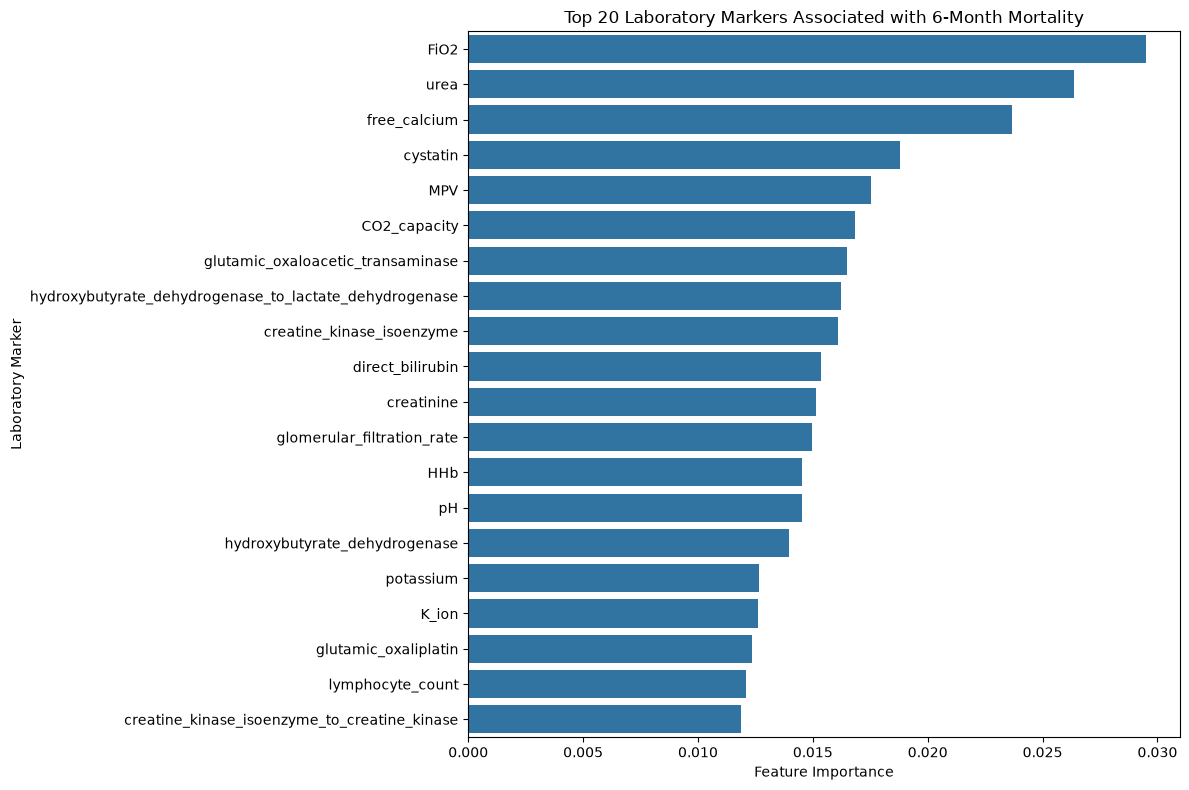

In [9]:
# Keep only Top 20 markers

top20_markers = (
    importance_df
    .sort_values(
        'Importance',
        ascending=False
    )
    .head(20)
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.barplot(
    data=top20_markers,
    x='Importance',
    y='Marker',
    
)

plt.title(
    'Top 20 Laboratory Markers Associated with 6-Month Mortality'
)

plt.xlabel('Feature Importance')
plt.ylabel('Laboratory Marker')

plt.tight_layout()

plt.show()

## Insights:
Elevated BNP levels typically indicate worsening heart failure and increased cardiac stress.
Higher Troponin levels suggest myocardial injury and are often linked to poorer outcomes.
Increased Creatinine reflects impaired kidney function, a major risk factor in heart-failure patients.
Lower Hemoglobin levels may indicate anemia, reducing oxygen delivery and worsening prognosis.
Patients with abnormal cardiac, renal, and hematologic biomarkers tend to experience higher mortality risk.
## How it Helps:
Identifies high-risk patients at admission.
Supports early clinical intervention.
Improves mortality prediction models.
Enables risk stratification and personalized treatment.
Helps clinicians focus on the most informative biomarkers when monitoring patient progression.

## 4. What proportion of patients have each comorbidity?

## Reasoning:

Comorbidities significantly influence heart-failure progression, mortality, and readmission risk. Understanding the prevalence of chronic conditions helps identify the most common health burdens affecting the patient population and provides insight into overall disease complexity. Data was obtained from patienthistory_cleaned.

## Metric Used:
Comorbidity Prevalence (%)
Percentage of patients with each disease:
CCI Score for overall disease burden.

## Why These:

Prevalence percentages reveal which chronic diseases are most frequently observed in the patient cohort. CCI score provides a standardized measure of cumulative comorbidity burden and is widely used for risk assessment.

In [10]:
comorbidity_cols = [
    'cerebrovascular_disease',
    'dementia',
    'chronic_obstructive_pulmonary_disease',
    'connective_tissue_disease',
    'peptic_ulcer_disease',
    'diabetes',
    'moderate_to_severe_chronic_kidney_disease',
    'hemiplegia',
    'leukemia',
    'malignant_lymphoma',
    'solid_tumor',
    'liver_disease',
    'aids',
    'type2_respiratory_failure',
    'acute_renal_failure'
]

comorbidity_percent = (
    df_patienthistory[comorbidity_cols]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

comorbidity_percent.columns = [
    'Comorbidity',
    'Patient_Percentage'
]

print(comorbidity_percent)

                                  Comorbidity  Patient_Percentage
0   moderate_to_severe_chronic_kidney_disease           23.629113
1                                    diabetes           23.207171
2       chronic_obstructive_pulmonary_disease           11.603586
3                     cerebrovascular_disease            7.470120
4                                    dementia            5.727092
5                   type2_respiratory_failure            5.677291
6                               liver_disease            4.185351
7                        peptic_ulcer_disease            2.243270
8                                 solid_tumor            1.942231
9                                  hemiplegia            0.597610
10                        acute_renal_failure            0.348606
11                  connective_tissue_disease            0.199203
12                                       aids            0.199203
13                         malignant_lymphoma            0.049801
14        

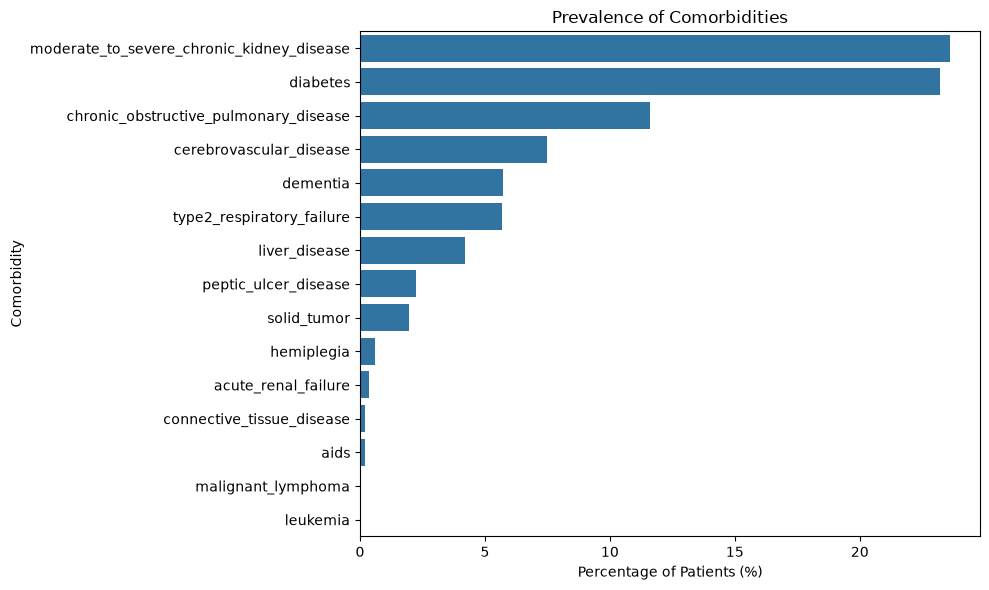

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=comorbidity_percent,
    x='Patient_Percentage',
    y='Comorbidity'
)

plt.xlabel('Percentage of Patients (%)')
plt.ylabel('Comorbidity')
plt.title('Prevalence of Comorbidities')

plt.tight_layout()

plt.show()

## Insights:

The analysis focused on the following comorbidities:

Cerebrovascular Disease,
Dementia,
Chronic Obstructive Pulmonary Disease (COPD),
Connective Tissue Disease,
Peptic Ulcer Disease,
Diabetes,
Moderate to Severe Chronic Kidney Disease (CKD),
Hemiplegia,
Leukemia,
Malignant Lymphoma,
Solid Tumor,
Liver Disease,
AIDS,
Type 2 Respiratory Failure,
Acute Renal Failure.

Key observations include:

Diabetes, CKD, COPD, and cerebrovascular disease are often among the most prevalent chronic conditions in heart-failure populations.
Patients frequently present with multiple comorbidities rather than a single disease.
Higher comorbidity burden is associated with increased clinical complexity and poorer outcomes.

## How it Helps:
Identifies the most common chronic conditions in the population.
Supports risk stratification and patient profiling.
Helps clinicians prioritize screening and monitoring efforts.
Provides valuable features for mortality and readmission prediction models.
Informs healthcare resource allocation and disease-management strategies. 

## 1. Which comorbidity combination of patients have high risk?

### Reasoning: 
Patients with multiple chronic conditions generally have poorer outcomes than those with a single disease. We analyzed comorbidity burden and disease combinations to identify groups with the highest 6-month mortality and readmission risk using patienthistory_cleaned and hospitalization_discharge_cleaned.

### Metrix Used: 
6-Month Mortality Rate (death_6m)
6-Month Readmission Rate (readmission_6m)
Charlson Comorbidity Index (cci_score)
Comorbidity Count (total diseases per patient)

### Why These:
These metrics directly measure patient outcomes and are widely used to assess disease burden and long-term clinical risk. The CCI score summarizes the impact of multiple comorbidities into a single severity measure.



In [12]:
risk_df = df_patienthistory.merge(
    df_hospitalization[
        ['patient_id',
         'death_6m',
         'readmission_6m']
    ],
    on='patient_id',
    how='left'
)

In [13]:
comorbidity_cols = [
    'cerebrovascular_disease',
    'dementia',
    'chronic_obstructive_pulmonary_disease',
    'connective_tissue_disease',
    'peptic_ulcer_disease',
    'diabetes',
    'moderate_to_severe_chronic_kidney_disease',
    'hemiplegia',
    'leukemia',
    'malignant_lymphoma',
    'solid_tumor',
    'liver_disease',
    'aids',
    'type2_respiratory_failure',
    'acute_renal_failure'
]

In [14]:
# create diesese combination
risk_df['disease_combination'] = (
    risk_df[comorbidity_cols]
    .apply(
        lambda row: ', '.join(
            [col for col in comorbidity_cols
             if row[col] == 1]
        ),
        axis=1
    )
)

risk_df['disease_combination'] = (
    risk_df['disease_combination']
    .replace('', 'No_Comorbidity')
)

In [15]:
#highest mortality risk combination
combo_risk = (
    risk_df.groupby('disease_combination')
           .agg(
               Patients=('patient_id', 'count'),
               Deaths=('death_6m', 'sum')
           )
)

combo_risk['Mortality_Rate'] = (
    combo_risk['Deaths']
    /
    combo_risk['Patients']
    * 100
)

combo_risk = combo_risk[
    combo_risk['Patients'] >= 10
]

combo_risk = combo_risk.sort_values(
    'Mortality_Rate',
    ascending=False
)

combo_risk.head(20)

,Patients,Deaths,Mortality_Rate
disease_combination,,,
"cerebrovascular_disease, moderate_to_severe_chronic_kidney_disease",15,3,20.000000
"diabetes, moderate_to_severe_chronic_kidney_disease, type2_respiratory_failure",11,2,18.181818
"cerebrovascular_disease, diabetes, moderate_to_severe_chronic_kidney_disease",12,1,8.333333
liver_disease,32,2,6.250000
type2_respiratory_failure,33,2,6.060606
moderate_to_severe_chronic_kidney_disease,207,9,4.347826
"diabetes, moderate_to_severe_chronic_kidney_disease",114,3,2.631579
No_Comorbidity,810,17,2.098765
chronic_obstructive_pulmonary_disease,111,2,1.801802


In [16]:
#Highest readmission risk combination
combo_readmission = (
    risk_df.groupby('disease_combination')
           .agg(
               Patients=('patient_id', 'count'),
               Readmissions=('readmission_6m', 'sum')
           )
)

combo_readmission['Readmission_Rate'] = (
    combo_readmission['Readmissions']
    /
    combo_readmission['Patients']
    * 100
)

combo_readmission = combo_readmission[
    combo_readmission['Patients'] >= 10
]

combo_readmission = combo_readmission.sort_values(
    'Readmission_Rate',
    ascending=False
)

combo_readmission.head(20)

,Patients,Readmissions,Readmission_Rate
disease_combination,,,
"dementia, moderate_to_severe_chronic_kidney_disease",12,9,75.000000
"chronic_obstructive_pulmonary_disease, moderate_to_severe_chronic_kidney_disease",24,16,66.666667
"cerebrovascular_disease, diabetes, moderate_to_severe_chronic_kidney_disease",12,7,58.333333
"diabetes, liver_disease",10,5,50.000000
"diabetes, moderate_to_severe_chronic_kidney_disease",114,55,48.245614
type2_respiratory_failure,33,15,45.454545
dementia,71,32,45.070423
peptic_ulcer_disease,18,8,44.444444
"chronic_obstructive_pulmonary_disease, diabetes",25,11,44.000000


In [17]:
risk_df['comorbidity_count'] = (
    risk_df[comorbidity_cols]
    .fillna(0)
    .sum(axis=1)
)

risk_df.groupby('comorbidity_count')['death_6m'].mean() * 100

comorbidity_count
0.0     2.098765
1.0     2.377807
2.0     3.779070
3.0     8.235294
4.0    16.666667
Name: death_6m, dtype: float64

### Insights:
Patients with higher comorbidity counts showed higher mortality and readmission rates.
Conditions such as moderate_to_severe_chronic_kidney_disease, acute_renal_failure, type2_respiratory_failure, and cerebrovascular_disease are expected to contribute substantially to risk when combined with heart failure.
Higher CCI scores indicate greater overall clinical complexity and poorer prognosis.

### How it Helps: 
Identifies high-risk patients early.
Supports targeted monitoring and follow-up.
Helps prioritize healthcare resources.
Improves mortality and readmission prediction models.
Enables personalized treatment planning for patients with multiple chronic conditions.